In [1]:
import pandas as pd

df = pd.read_csv('data/wine_cleared.csv')

In [2]:
df

,Unnamed: 0,country,description,designation,points,price,province,region_1,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,35.363389,Sicily & Sardinia,Etna,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.000000,Douro,unknown,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",unknown,87,14.000000,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.000000,Michigan,Lake Michigan Shore,Alexander Peartree,unknown,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.000000,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129966,129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.000000,Mosel,unknown,Anna Lee C. Iijima,unknown,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,129967,US,Citation is given as much as a decade of bottl...,unknown,90,75.000000,Oregon,Oregon,Paul Gregutt,@paulgwine,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.000000,Alsace,Alsace,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,129969,France,"A dry style of Pinot Gris, this is crisp with ...",unknown,90,32.000000,Alsace,Alsace,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss


In [3]:
import statistics

In [4]:

avg_price = round(statistics.mean(df['price']), 2)
print(avg_price)

35.36


In [5]:
med_price = round(statistics.median(df['price']), 2)
print(med_price)

28.0


In [6]:
moda_price = round(statistics.mode(df['price']), 2)
print(moda_price)

35.36


In [7]:
corr_value = round(df['price'].corr(df['points']), 6)
print(corr_value)

0.402137


In [8]:
corr_value = round(df['points'].corr(df['price']), 6)
print(corr_value)


0.402137


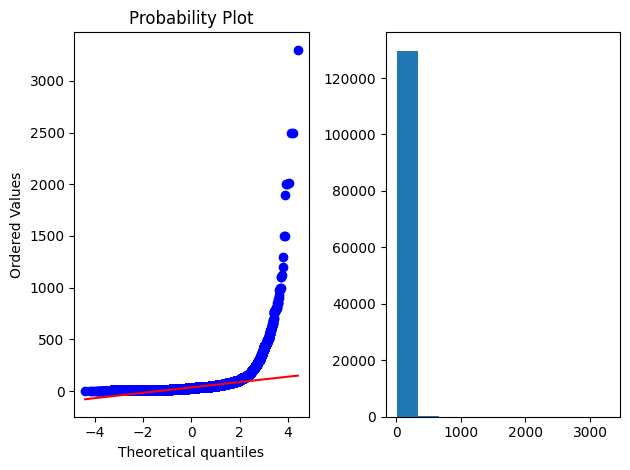

In [9]:
import matplotlib.pyplot as plt
from scipy import stats

plt.subplot(1, 2, 1)
stats.probplot(df['price'], plot=plt)  # QQ plot

plt.subplot(1, 2, 2)
plt.hist(df['price'])  # гистограмма распределения признака

plt.tight_layout()  # чтобы графики не наезжали друг на друга
plt.show()  # покажет оба графика сразу (QQ plot и гистограмму)

In [10]:
corr_spearman = round(df['price'].corr(df['points'], method='spearman'), 2)
print(corr_spearman)

0.58


In [11]:
corr_kendall = round(df['points'].corr(df['price'], method='kendall'), 2)
print(corr_kendall)


0.43


In [12]:
from sklearn.metrics import matthews_corrcoef

x = [+1, -1, +1, +1] # список значений признака х
y = [+1, +1, +1, -1] # список значений признака y

matthews_corrcoef(x, y) # рассчитаем коэффициент корреляции Мэтьюса

-0.3333333333333333

In [13]:
# Превратим оценки и цены в бинарные признаки (например, выше медианы = 1, ниже = 0)
points_binary = (df['points'] > df['points'].median()).astype(int)
price_binary = (df['price'] > df['price'].median()).astype(int)

mcc = round(matthews_corrcoef(points_binary, price_binary), 2)
print(mcc)


0.41
